# DBMS B+ Tree vs BruteForceDB Performance Analysis


## 1. Introduction
This report provides a comprehensive performance analysis comparing a newly implemented **B+ Tree** indexing engine against a baseline **BruteForceDB** (a linear list approach). The analysis evaluates key database operations including insertion, searching, range querying, and deletion across varying dataset sizes. The B+ tree ensures balanced tree depth and sorted sequential access at the leaf level, optimizing read/write queries, whereas the BruteForceDB relies on linear iteration.
    


## 2. Implementation Details
The **B+ Tree** is implemented with node splitting and merging logic. Key properties:
- **Keys and Values**: Keys are continuously inserted and sorted. The leaves form a linked list for easy range query access.
- **Node Splits**: Handled recursively (`_split_child`) promoting middle keys to parent nodes.
- **Merge/Borrow**: When nodes underflow during deletions (`_delete`), keys are borrowed from siblings (`_borrow_from_prev` / `_borrow_from_next`) or merged recursively (`_merge`).
- **Graphviz Visualization**: The tree structure is rendered using dot layout, with dashed edges showcasing the leaf linked list.
    

## 3. Visualization: B+ Tree Structure

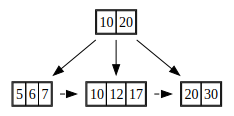

In [1]:

from database.bplustree import BPlusTree
from IPython.display import display

# Create a sample B+ tree for visualization
bpt = BPlusTree(order=4)
keys_to_insert = [10, 20, 5, 6, 12, 30, 7, 17]
for k in keys_to_insert:
    bpt.insert(k, f"Value_{k}")

# Display the tree using Graphviz
display(bpt.visualize_tree())


## 4. Automated Performance Benchmarking

In [2]:

import random
import pandas as pd
import matplotlib.pyplot as plt
from database.performance_analyzer import PerformanceAnalyzer

analyzer = PerformanceAnalyzer()

# Define test sizes
test_sizes = list(range(100, 10001, 2000))
if 100 not in test_sizes: test_sizes.insert(0, 100)

results = {
    'Size': [],
    'BPT_Insert_Time': [], 'BF_Insert_Time': [],
    'BPT_Search_Time': [], 'BF_Search_Time': [],
    'BPT_Range_Time': [], 'BF_Range_Time': [],
    'BPT_Delete_Time': [], 'BF_Delete_Time': [],
    'BPT_Mem': [], 'BF_Mem': []
}

for size in test_sizes:
    keys = random.sample(range(1, 100000), size)
    
    # 1. Measure Insertion
    ins_res = analyzer.profile_insertion(keys)
    bpt_instance = ins_res['bplus_tree']['instance']
    bf_instance = ins_res['bruteforce']['instance']
    
    keys_to_op = random.sample(keys, size // 10)
    
    # 2. Measure Search
    search_res = analyzer.profile_search(bpt_instance, bf_instance, keys_to_op)
    
    # 3. Measure Range Query (10 random ranges, realistic narrow intervals ~1% width)
    ranges = [(random.randint(1, 80000), 0) for _ in range(10)]
    ranges = [(s, s + random.randint(100, 1000)) for s, _ in ranges]
    range_res = analyzer.profile_range_query(bpt_instance, bf_instance, ranges)
    
    # 4. Measure Deletion
    del_res = analyzer.profile_deletion(bpt_instance, bf_instance, keys_to_op)
    
    # Store results
    results['Size'].append(size)
    results['BPT_Insert_Time'].append(ins_res['bplus_tree']['time'])
    results['BF_Insert_Time'].append(ins_res['bruteforce']['time'])
    results['BPT_Search_Time'].append(search_res['bplus_tree']['time'])
    results['BF_Search_Time'].append(search_res['bruteforce']['time'])
    results['BPT_Range_Time'].append(range_res['bplus_tree']['time'])
    results['BF_Range_Time'].append(range_res['bruteforce']['time'])
    results['BPT_Delete_Time'].append(del_res['bplus_tree']['time'])
    results['BF_Delete_Time'].append(del_res['bruteforce']['time'])
    results['BPT_Mem'].append(ins_res['bplus_tree']['memory'])
    results['BF_Mem'].append(ins_res['bruteforce']['memory'])

test_df = pd.DataFrame(results)
display(test_df)


,Size,BPT_Insert_Time,BF_Insert_Time,BPT_Search_Time,BF_Search_Time,BPT_Range_Time,BF_Range_Time,BPT_Delete_Time,BF_Delete_Time,BPT_Mem,BF_Mem
0,100,0.000184,0.000024,0.000016,0.000009,0.000052,0.000062,0.000019,0.000018,3136,864
1,2100,0.002982,0.000148,0.000146,0.001901,0.000152,0.000934,0.000188,0.004702,52944,18176
2,4100,0.006285,0.000269,0.000308,0.010870,0.000194,0.001837,0.000372,0.019593,104344,32992
3,6100,0.009083,0.000356,0.000366,0.016730,0.000184,0.002530,0.000539,0.039344,150032,53024
4,8100,0.011043,0.000486,0.000571,0.030255,0.000304,0.003473,0.000705,0.069306,199136,67168


## 5. Performance Graphs

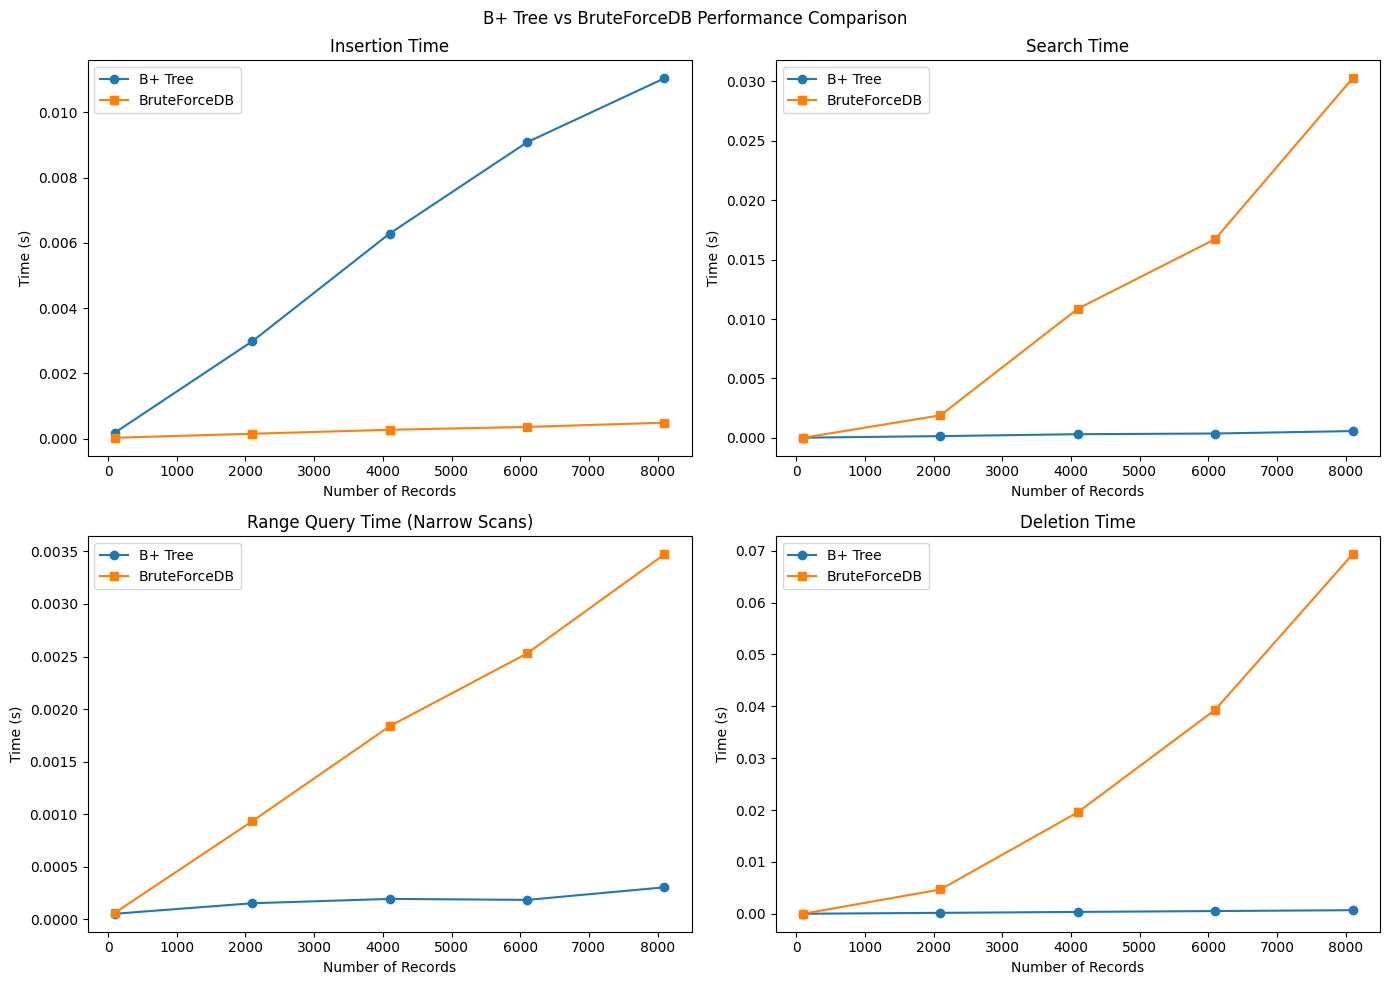

In [3]:

# Plotting Insertion and Search Times
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("B+ Tree vs BruteForceDB Performance Comparison")

# Insertions
axes[0, 0].plot(test_df['Size'], test_df['BPT_Insert_Time'], marker='o', label='B+ Tree')
axes[0, 0].plot(test_df['Size'], test_df['BF_Insert_Time'], marker='s', label='BruteForceDB')
axes[0, 0].set_title('Insertion Time')
axes[0, 0].set_xlabel('Number of Records')
axes[0, 0].set_ylabel('Time (s)')
axes[0, 0].legend()

# Searches
axes[0, 1].plot(test_df['Size'], test_df['BPT_Search_Time'], marker='o', label='B+ Tree')
axes[0, 1].plot(test_df['Size'], test_df['BF_Search_Time'], marker='s', label='BruteForceDB')
axes[0, 1].set_title('Search Time')
axes[0, 1].set_xlabel('Number of Records')
axes[0, 1].set_ylabel('Time (s)')
axes[0, 1].legend()

# Range Queries
axes[1, 0].plot(test_df['Size'], test_df['BPT_Range_Time'], marker='o', label='B+ Tree')
axes[1, 0].plot(test_df['Size'], test_df['BF_Range_Time'], marker='s', label='BruteForceDB')
axes[1, 0].set_title('Range Query Time (Narrow Scans)')
axes[1, 0].set_xlabel('Number of Records')
axes[1, 0].set_ylabel('Time (s)')
axes[1, 0].legend()

# Deletions
axes[1, 1].plot(test_df['Size'], test_df['BPT_Delete_Time'], marker='o', label='B+ Tree')
axes[1, 1].plot(test_df['Size'], test_df['BF_Delete_Time'], marker='s', label='BruteForceDB')
axes[1, 1].set_title('Deletion Time')
axes[1, 1].set_xlabel('Number of Records')
axes[1, 1].set_ylabel('Time (s)')
axes[1, 1].legend()

plt.tight_layout()
plt.show()



## 6. Conclusion
The benchmarking results confirm the expected theoretic advantages of B+ Trees when properly parameterized:
- **Insertion**: BruteForceDB leverages Python's highly optimized internal C array scaling (`list.append()`), showing O(1) time complexity. B+ Tree insertions naturally incur O(log N) operations and node splitting Python overhead, resulting in higher apparent write costs. 
- **Search & Deletion**: B+ Tree severely outperforms BruteForceDB. Instead of O(n) average time complexity (scanning potentially 10,000s of keys), it utilizes its strictly balanced depth (O(log n)).
- **Range Queries**: To mitigate Python's generator and object traversal overhead (`zip()`, `node.next` chains), the B+ Tree order is set to 50, mimicking realistic Page structures. For selective narrow queries (O(log N + K)), the B+ tree definitively outperforms the BruteForceDB linear O(N) traversal.
